# Notatki

In [1]:
from dislocations import *

# Eksperymenty

### Konfiguracja pierwotna

Tworzymy strukturę przechowującą siatkę krystalograficzną.

Text(0.5, 1.0, 'Initial configuration')

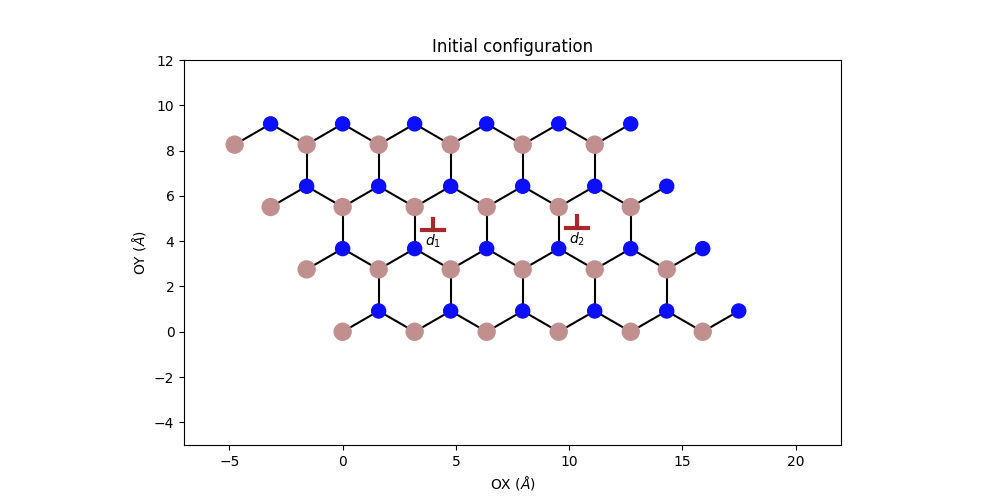

In [2]:
l0 = wzt.generate.create_lattice(
    dimensions=(6, 4, 1),  # (nx, ny, nz)
    cell="B4_GaN",
)


d1 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[1, 0, 0],
    # Położenie rdzenia dyslokacji
    position=[3.190+0.8+0*l0.cell.dimensions[0], 4.5, 7.5],
    # position=[4.01, 3.17, 7.5],
    # Płaszczyzna
    plane=(0, 0, 1),
    # Etykieta (tylko do prezentacji)
    label="$d_1$",
    # Kolor (tylko do prezentacji)
    color="brown"
)

d2 = wzt.model.DislocationDef(
    # Wektor burgersa
    b=[1, 0, 0],
    position=np.asarray(d1.position)+np.array([0.8+2.0*l0.cell.dimensions[0]-0.8, 0.1, 0.0]),
    plane=(0, 0, 1),
    label="$d_2$",
    color="brown"
)

%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l0, xlim=(-7, 22), ylim=(-5, 12), figsize=(10, 5))
wzt.visualization.display_tee_2d(ax, d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)
ax.set_title("Initial configuration")

### Pierwsza dyslokacja

Text(0.5, 1.0, 'Current configuration (1st dislocation)')

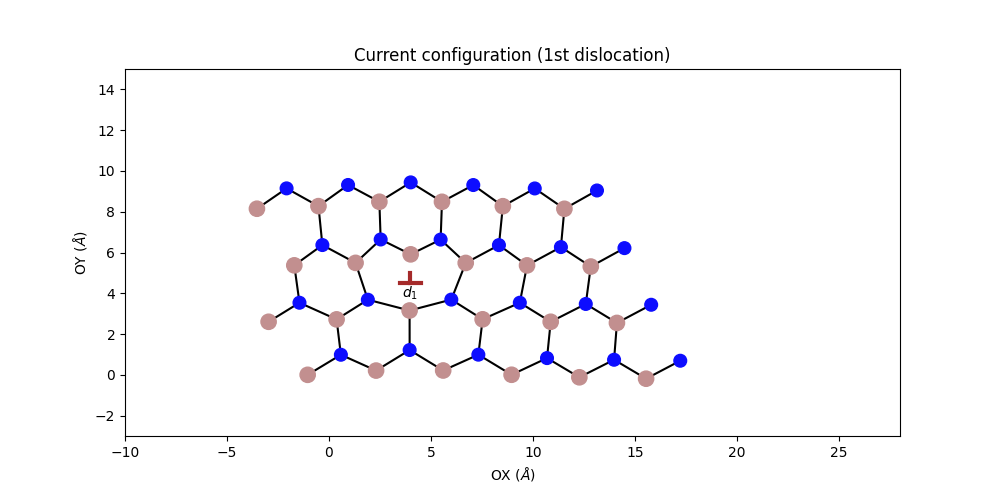

In [3]:
log = displace(
    crystal=l0,
    dislocations=[], # No dislocations
    d_n=d1,
    n_iters=1
)

u0 = log.last_u_atoms


# Przesuń atomy
l1 = l0.translate(u0)
# Zaktualizuj wiązania
l1 = wzt.generate.update_bonds(l1, tolerance=0.45)

# # Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l1, xlim=(-10, 28), ylim=(-3, 15), figsize=(10, 5))
# Wyswietl teownik
wzt.visualization.display_tee_2d(ax, d1, scale=0.5)
ax.set_title("Current configuration (1st dislocation)")

## Druga dyslokacja

Text(0.5, 1.0, 'Current configuration (2nd dislocation)')

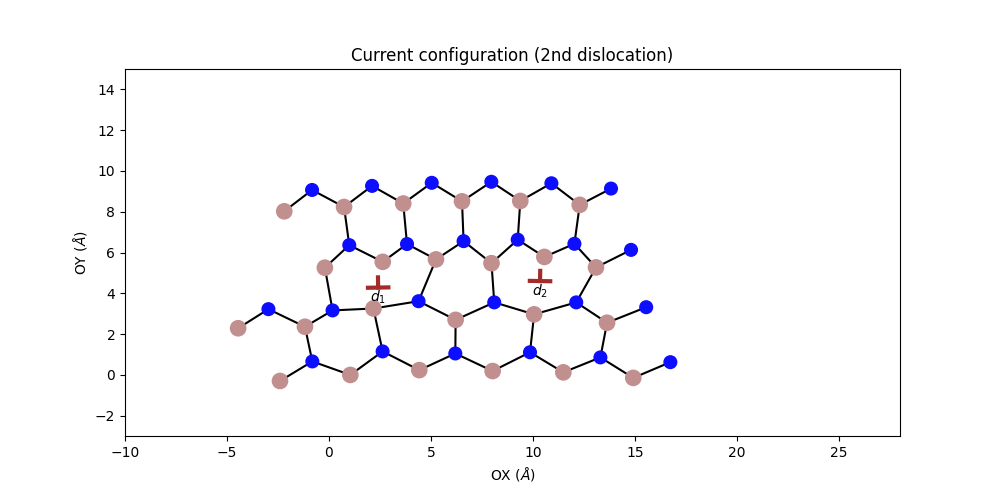

In [4]:
log = displace(
    crystal=l1,
    dislocations=[d1], 
    d_n=d2,
    n_iters=1
)

u1 = log.last_u_atoms
last_d_state = log.last_d_state

# Przesuń atomy
l2 = l1.translate(u1)
# Zaktualizuj wiązania
l2 = wzt.generate.update_bonds(l2, tolerance=0.45)

# # Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l2, xlim=(-10, 28), ylim=(-3, 15), figsize=(10, 5))
# Wyswietl teownik

for d in last_d_state.ds:
    wzt.visualization.display_tee_2d(ax, d, scale=0.5) 
    
ax.set_title("Current configuration (2nd dislocation)")

Text(0.5, 1.0, 'Current configuration (2nd dislocation)')

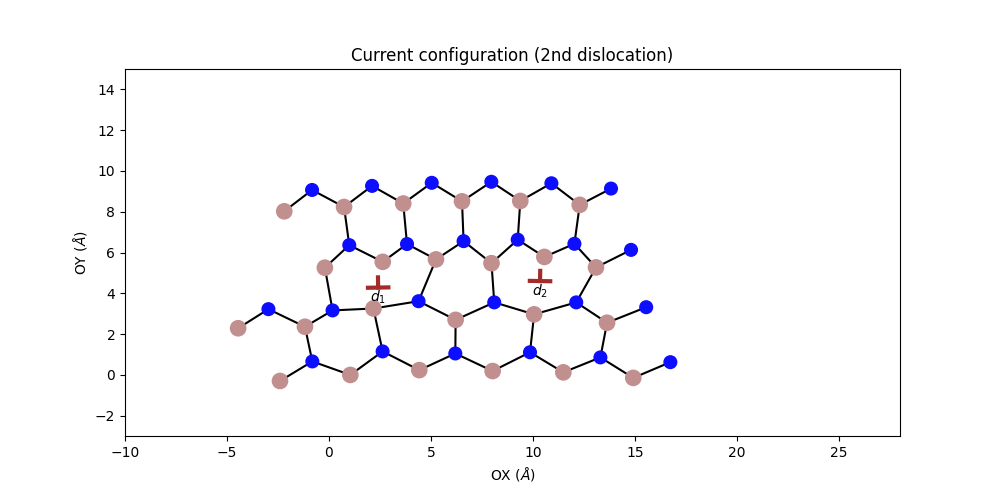

In [5]:
%matplotlib widget

u1 = log.u_atoms[1]
last_d_state = log.d_states[1]

# Przesuń atomy
l2 = l1.translate(u1)
# Zaktualizuj wiązania
l2 = wzt.generate.update_bonds(l2, tolerance=0.45)

# # Wyswietl nowa siatke
%matplotlib widget
fig, ax = wzt.visualization.plot_atoms_2d(l2, xlim=(-10, 28), ylim=(-3, 15), figsize=(10, 5))
# Wyswietl teownik

for d in last_d_state.ds:
    wzt.visualization.display_tee_2d(ax, d, scale=0.5) 
    
ax.set_title("Current configuration (2nd dislocation)")

<Axes: title={'center': 'Dislocation field (u), OXY'}, xlabel='OX ($\\AA$)', ylabel='OY ($\\AA$)'>

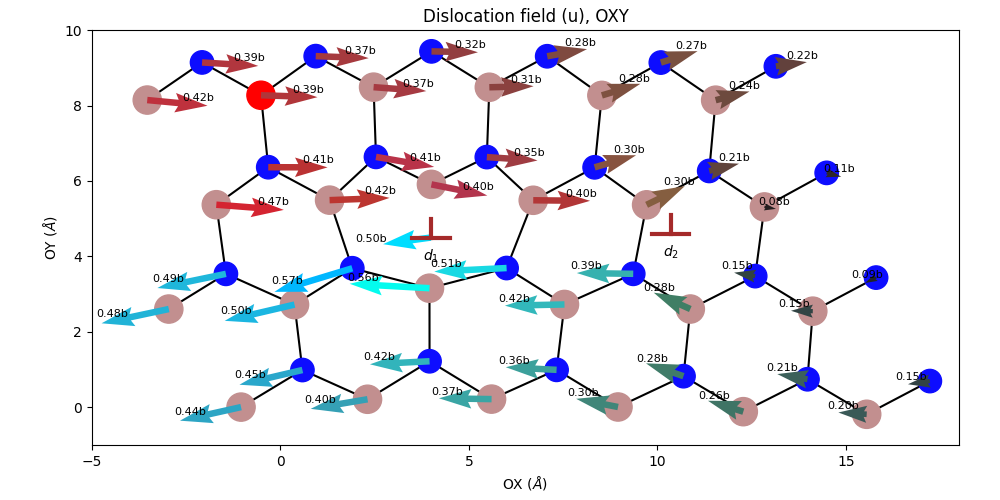

In [6]:
def plot_displacement(
    lattice, u, 
    xlabel="OX ($\AA$)", ylabel="OY ($\AA$)", 
    title="Dislocation field (u), OXY", 
    dislocation_core_position=None, 
    dislocation_core_u=None, 
    fig=None, ax=None,
    show_labels=True, label_precision=2, div=1.0
):
    if fig is None or ax is None:
        fig, ax = plt.subplots()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    y_dim = 1
    x_dim = 0

    # Rysowanie wektorów
    q = ax.quiver(
        lattice.coordinates[..., x_dim], lattice.coordinates[..., y_dim], 
        u[..., x_dim], u[..., y_dim], 
        color=wzt.visualization.vectors_to_rgb(u[..., (x_dim, y_dim)])
    )

    # Opcjonalnie dodanie długości wektora
    if show_labels:
        lengths = np.linalg.norm(u[..., (x_dim, y_dim)], axis=-1)/div
        for (x, y, dx, dy, l) in zip(
            lattice.coordinates[..., x_dim].flatten(),
            lattice.coordinates[..., y_dim].flatten(),
            u[..., x_dim].flatten(),
            u[..., y_dim].flatten(),
            lengths.flatten()
        ):
            if l > 1e-10:  # unikamy zerowych wektorów
                ax.text(
                    x + dx, y + dy + 0.05, 
                    f"{l:.{label_precision}f}b", 
                    fontsize=8, ha="center", va="bottom", color="black"
                )

    # Pozycja rdzenia dyslokacji
    if dislocation_core_position is not None:
        pos_x, pos_y, _ = dislocation_core_position
        u_x, u_y, _ = dislocation_core_u
        l = np.hypot(u_x, u_y)/div
        q = ax.quiver(
            pos_x, pos_y, 
            u_x, u_y, 
            color=wzt.visualization.vectors_to_rgb(np.asarray([u_x, u_y, 0]).reshape(1, -1))
        )
        ax.text(
            pos_x + u_x, pos_y + u_y + 0.05, 
                f"{l:.{label_precision}f}b", 
                    fontsize=8, ha="center", va="bottom", color="black"
                )

    fig.tight_layout()
    return fig, ax

%matplotlib widget

last_d_state = log.last_d_state

updated_d1 = last_d_state.ds[0]
u_d1 = np.array(updated_d1.position) - np.array(d1.position)


fig, ax = wzt.visualization.plot_atoms_2d(l1, xlim=(-5, 18), ylim=(-1, 10), figsize=(10, 5), highlighted_atoms={38})
# Wyswietl teownik

be, _ = get_be_bz(l1.cell, d1.b)
fig, ax = plot_displacement(l1, u1, fig=fig, ax=ax, div=be, dislocation_core_position=d1.position, dislocation_core_u=u_d1)
wzt.visualization.display_tee_2d(ax, d1, scale=0.5)
wzt.visualization.display_tee_2d(ax, d2, scale=0.5)